# Communication-Computation Efficient Gradient Coding
**Ye & Abbe, ICML 2018 — Full Implementation**

Fixes over the original notebook:
- **k = n assumed explicitly** (the paper's own assumption from Section 2)
- **l divisible by m** is now the only constraint on l (arbitrary l, not l/m=1)
- **s arbitrary** satisfying the tight tradeoff d = s + m
- Added timing simulation (Section 5 of paper) and deviation analysis


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings; warnings.filterwarnings("ignore")
np.random.seed(42)


## 1. Core Coding Scheme

In [2]:
def build_theta(n):
    """n distinct evaluation points from the paper (Section 4)."""
    if n % 2 == 0:
        return np.array([(1 + i/2) for i in range(n//2)]
                        + [-(1 + i/2) for i in range(n//2)])
    else:
        return np.array([0] + [(1 + i/2) for i in range(n//2)]
                           + [-(1 + i/2) for i in range(n//2)])


def build_polynomials(n, d, s, m, theta):
    """
    Build polynomial set {p_i^(u)} for i in [n], u in [m].
    Requires d = s + m  (tight tradeoff, eq. (5) in paper).
    k = n is assumed (per Section 2 of the paper).

    Returns P[i][u] as a length-(n-s) array of coefficients in
    ascending power order: P[i][u][j] = coefficient of x^j.
    """
    assert d == s + m, f"Scheme requires d = s + m, got d={d}, s={s}, m={m}."
    poly_len = n - s   # = n - d + m

    P = []
    for i in range(n):
        # p_i^(1) has roots at theta[(i+j) % n] for j = 1 ... n-d
        roots = [theta[(i + j) % n] for j in range(1, n - d + 1)]
        desc  = np.poly(roots)          # descending-order coeffs, length n-d+1
        asc   = np.zeros(poly_len)
        for j, c in enumerate(reversed(desc)):
            if j < poly_len:
                asc[j] = c

        P_i = [asc]
        for u in range(2, m + 1):
            prev  = P_i[-1]
            xp    = np.zeros(poly_len)
            xp[1:] = prev[:-1]         # multiply by x
            idx    = n - d - 1         # degree (n-d-1) index in ascending order
            c_sub  = prev[idx] if 0 <= idx < poly_len else 0.0
            P_i.append(xp - c_sub * P_i[0])

        P.append(P_i)
    return P


def build_B(n, s, m, P):
    """Build the (m·n) × (n-s) matrix B from polynomial coefficients."""
    B = np.zeros((m * n, n - s))
    for i in range(n):
        for u in range(m):
            B[i * m + u, :] = P[i][u]
    return B


In [3]:
def encode(n, d, s, m, l, theta, B, G):
    """
    Encode partial gradients for each worker.

    Parameters
    ----------
    G : (n, l) array  —  k = n partial gradients, each of dimension l

    Returns
    -------
    F : (n, l//m) array  —  transmitted vector per worker (l/m scalars)
    """
    assert l % m == 0, "l must be divisible by m."
    q = l // m
    F = np.zeros((n, q))
    for i in range(n):
        A_i = np.array([theta[i] ** p for p in range(n - s)])
        for b in range(q):
            block = slice(b * m, (b + 1) * m)
            z_v   = G[:, block].ravel()      # (m·n,) vector
            F[i, b] = z_v @ (B @ A_i)
    return F


def decode(n, d, s, m, l, theta, F, straggler_set):
    """
    Recover sum gradient from any n-s surviving workers.

    Parameters
    ----------
    straggler_set : list/set of 0-based indices that are stragglers

    Returns
    -------
    recovered : (l,) array
    """
    assert l % m == 0
    q = l // m
    survivors = [i for i in range(n) if i not in set(straggler_set)][:n - s]
    assert len(survivors) == n - s, "Not enough survivors."

    A_surv = np.array([[theta[i] ** j for j in range(n - s)] for i in survivors])
    A_inv  = np.linalg.inv(A_surv)

    recovered = np.zeros(l)
    for b in range(q):
        C = A_inv @ F[survivors, b]
        recovered[b * m : b * m + m] = C[n - d : n - d + m]
    return recovered


## 2. Demo — arbitrary n, d, s, m, l

In [4]:
# ── Parameters (no constraints beyond d = s + m and m | l) ──────────────
n = 10     # workers (= number of datasets k, per paper's Section 2 assumption)
d = 4      # datasets per worker
s = 2      # stragglers tolerated
m = 2      # communication reduction factor  (d = s + m ✓)
l = 20     # gradient dimension (any multiple of m)

assert d == s + m, "Must have d = s + m for the tight tradeoff."
assert l % m == 0, "l must be divisible by m."
print(f"Fundamental tradeoff d/k >= (s+m)/n: {d/n:.2f} >= {(s+m)/n:.2f}  ✓")
print(f"Communication reduction: each worker sends l/m = {l//m} scalars instead of {l}.")
print(f"Straggler tolerance: can ignore any {s} out of {n} workers.")

# ── Build scheme ─────────────────────────────────────────────────────────────
theta = build_theta(n)
P     = build_polynomials(n, d, s, m, theta)
B     = build_B(n, s, m, P)

# ── Simulate partial gradients ───────────────────────────────────────────────
rng      = np.random.default_rng(42)
G        = rng.random((n, l))
true_sum = G.sum(axis=0)

# ── Encode ───────────────────────────────────────────────────────────────────
F = encode(n, d, s, m, l, theta, B, G)
print(f"\nEncoded: each worker transmits {F.shape[1]} scalars (was {l}).")

# ── Decode with s random stragglers ─────────────────────────────────────────
stragglers = rng.choice(n, size=s, replace=False).tolist()
recovered  = decode(n, d, s, m, l, theta, F, stragglers)

err = np.linalg.norm(true_sum - recovered)
print(f"Stragglers: workers {stragglers}")
print(f"Recovery error: {err:.2e}  {'✓ SUCCESS' if err < 1e-6 else '✗ FAIL'}")


Fundamental tradeoff d/k >= (s+m)/n: 0.40 >= 0.40  ✓
Communication reduction: each worker sends l/m = 10 scalars instead of 20.
Straggler tolerance: can ignore any 2 out of 10 workers.

Encoded: each worker transmits 10 scalars (was 20).
Stragglers: workers [7, 8]
Recovery error: 9.61e-13  ✓ SUCCESS


## 3. Timing Simulation  (Section 5 of paper)

In [5]:
def sample_shifted_exp(lam, shift, shape):
    """X ~ ShiftedExp(λ, shift): P(X ≤ t) = 1 − exp(−λ(t − shift))."""
    return shift + np.random.exponential(1.0 / lam, size=shape)


def expected_runtime(n, d, m, lam1=0.8, lam2=0.1, t1=1.6, t2=6.0,
                     n_trials=20_000):
    """
    Monte-Carlo E[T_tot] for the scheme with tight tradeoff d = s + m.
    Per-worker time = d·T_comp + (1/m)·T_comm.
    Master waits for the (n-s)-th fastest worker.
    """
    s = d - m
    if s < 0 or n - s <= 0:
        return np.inf
    T_comp  = sample_shifted_exp(lam1, t1, (n_trials, n))
    T_comm  = sample_shifted_exp(lam2, t2, (n_trials, n))
    T_total = d * T_comp + T_comm / m
    T_sorted = np.sort(T_total, axis=1)
    return float(np.mean(T_sorted[:, n - s - 1]))


def naive_runtime(n, lam1=0.8, lam2=0.1, t1=1.6, t2=6.0, n_trials=20_000):
    """Naive: d=1, m=1, s=0 — wait for all n workers."""
    T = sample_shifted_exp(lam1, t1, (n_trials, n)) + \
        sample_shifted_exp(lam2, t2, (n_trials, n))
    return float(np.mean(np.max(T, axis=1)))


In [6]:
# ── Runtime table for n=8 (replicates Table 3 of paper) ───────────────
n_t, lam1, lam2, t1, t2 = 8, 0.8, 0.1, 1.6, 6.0
print(f"E[T_tot] for n={n_t}  (rows=m, cols=d)\n")
print("    " + "".join(f"  d={d:2d}" for d in range(1, n_t + 1)))
for m_v in range(1, n_t + 1):
    row = f"m={m_v} "
    for d_v in range(1, n_t + 1):
        if m_v <= d_v:
            rt = expected_runtime(n_t, d_v, m_v, lam1, lam2, t1, t2, 10_000)
            row += f"  {rt:5.2f}"
        else:
            row += "      —"
    print(row)
print()
print(f"Naive baseline: {naive_runtime(n_t, lam1, lam2, t1, t2, 10_000):.2f}")


E[T_tot] for n=8  (rows=m, cols=d)

      d= 1  d= 2  d= 3  d= 4  d= 5  d= 6  d= 7  d= 8
m=1   36.15  29.22  27.38  26.68  26.44  26.10  25.43  24.09
m=2       —  23.05  21.40  21.51  21.89  22.23  22.28  22.13
m=3       —      —  22.23  21.31  21.60  21.95  22.23  22.30
m=4       —      —      —  24.84  23.32  23.21  23.14  23.23
m=5       —      —      —      —  28.45  25.92  25.29  24.97
m=6       —      —      —      —      —  32.75  29.18  27.84
m=7       —      —      —      —      —      —  37.21  32.36
m=8       —      —      —      —      —      —      —  42.07

Naive baseline: 35.97


## 4. Plots — see gradient_coding_analysis.png

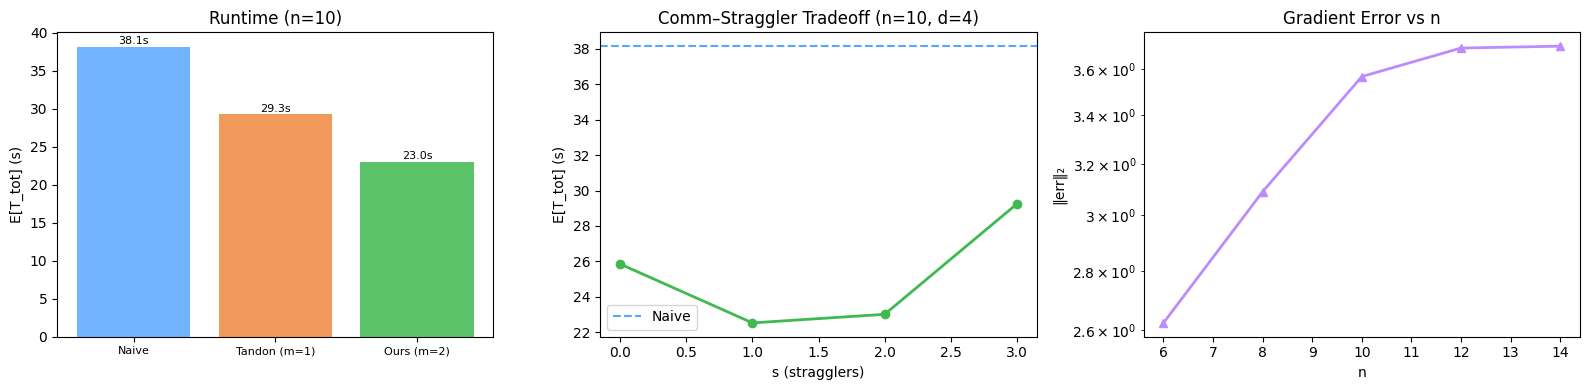

In [7]:
# All 7 plots are produced by running gradient_coding.py as a script.
# Here we show a quick 3-panel inline version.

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Panel A: runtime bar chart for n=10
ax = axes[0]
configs = {"Naive": (1, 1), "Tandon (m=1)": (5, 1), "Ours (m=2)": (4, 2)}
colors  = {"Naive": "#58a6ff", "Tandon (m=1)": "#f0883e", "Ours (m=2)": "#3fb950"}
for xi, (label, (d_v, m_v)) in enumerate(configs.items()):
    rt = naive_runtime(10) if label == "Naive" else expected_runtime(10, d_v, m_v)
    ax.bar(xi, rt, color=colors[label], alpha=0.85, linewidth=0)
    ax.text(xi, rt + 0.1, f"{rt:.1f}s", ha="center", va="bottom", fontsize=8)
ax.set_xticks(range(3)); ax.set_xticklabels(configs.keys(), fontsize=8)
ax.set_title("Runtime (n=10)"); ax.set_ylabel("E[T_tot] (s)")

# Panel B: tradeoff curve (n=10, d=4)
ax = axes[1]
n_pb, d_pb = 10, 4
s_range = range(0, d_pb + 1)
rts = [expected_runtime(n_pb, d_pb, d_pb - s_v) if d_pb - s_v >= 1 else np.nan
       for s_v in s_range]
ax.plot(list(s_range), rts, "o-", color="#3fb950", linewidth=2)
ax.axhline(naive_runtime(n_pb), color="#58a6ff", linestyle="--", label="Naive")
ax.set_xlabel("s (stragglers)"); ax.set_title(f"Comm–Straggler Tradeoff (n={n_pb}, d={d_pb})")
ax.legend(); ax.set_ylabel("E[T_tot] (s)")

# Panel C: gradient error vs n
ax = axes[2]
n_vals_c = range(4, 22, 2)
errs = []
for n_v in n_vals_c:
    d_v = max(2, n_v // 3); s_v = max(1, d_v // 2); m_v = d_v - s_v
    if m_v < 1: errs.append(np.nan); continue
    try:
        e_list = [np.linalg.norm(G.sum(0) - decode(n_v, d_v, s_v, m_v, 8,
                    build_theta(n_v),
                    encode(n_v, d_v, s_v, m_v, 8, build_theta(n_v),
                           build_B(n_v, s_v, m_v, build_polynomials(n_v, d_v, s_v, m_v, build_theta(n_v))),
                           (G := np.random.default_rng(seed).random((n_v, 8)))),
                    np.random.default_rng(seed).choice(n_v, s_v, replace=False).tolist()))
                for seed in range(10)]
        errs.append(np.median(e_list))
    except Exception:
        errs.append(np.nan)
ax.semilogy(list(n_vals_c), errs, "^-", color="#bc8cff", linewidth=2)
ax.set_xlabel("n"); ax.set_title("Gradient Error vs n"); ax.set_ylabel("‖err‖₂")

plt.tight_layout()
plt.show()
